# Régression logistique

CSI 4506 - automne 2026

Marcel Turcotte  
Version : 21 septembre 2026 09h35

# Préambule

## Message du jour

[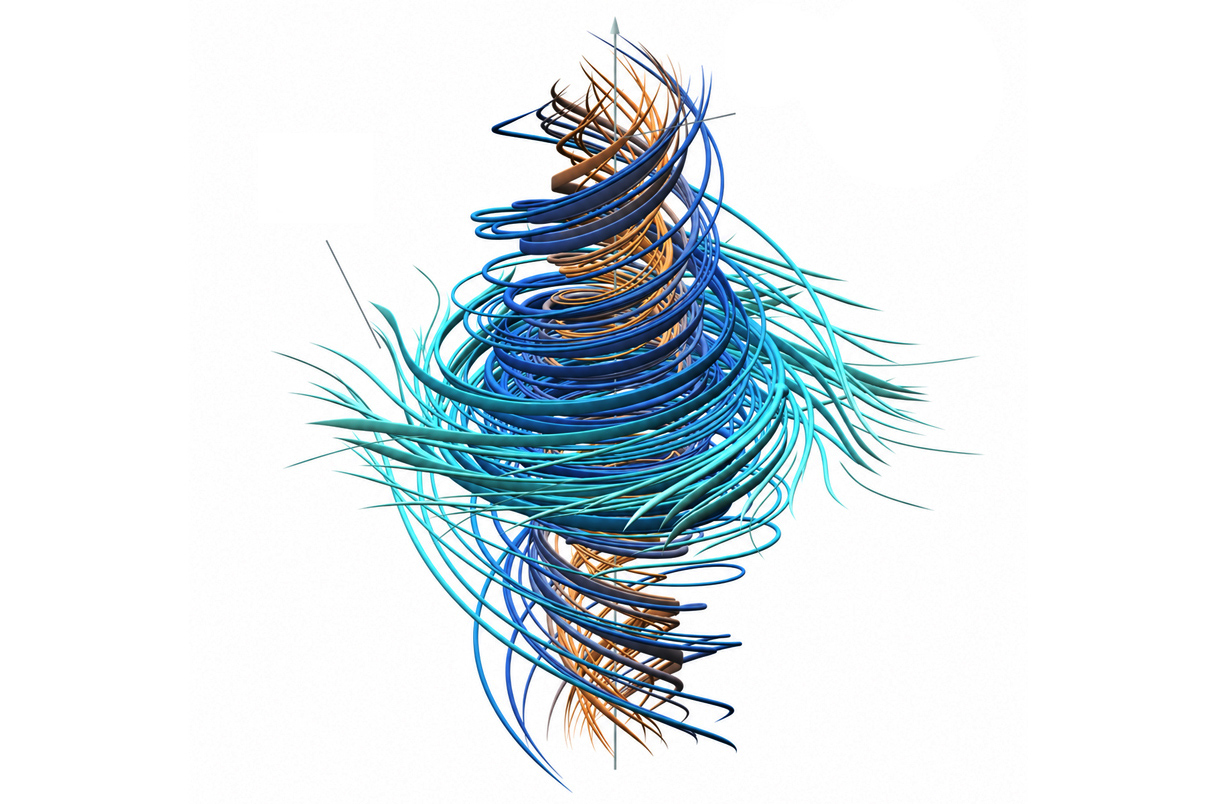](https://www.science.org/content/article/openai-breakthrough-triggers-existential-crisis-math)

[“OpenAI breakthrough triggers ‘existential crisis’ in
math”](https://www.science.org/content/article/openai-breakthrough-triggers-existential-crisis-math),
C. Zhao, *Science*, 2026-09-15.

Le 8 septembre, OpenAI a annoncé qu’un système d’IA interne avait
produit une solution au problème d’existence et de régularité des
équations de Navier–Stokes, l’un des problèmes du prix du millénaire.
OpenAI a publié à la fois une démonstration écrite et une formalisation
en Lean. La communauté mathématique examine toujours le résultat; il
faut donc parler d’une **solution annoncée**, et non d’un résultat
définitivement établi (Zhao 2026).

Ici, la « crise existentielle » désigne un débat sur la raison d’être et
l’avenir des mathématiques, et non une menace existentielle pour
l’humanité. L’article demande ce que signifie comprendre les
mathématiques lorsqu’un système d’IA produit une démonstration
formellement vérifiée que les humains peinent à comprendre. Il soulève
aussi des questions sur l’attribution du mérite et sur l’accès inégal
aux ressources informatiques requises pour ce type de recherche.

- Une démonstration formellement vérifiée procure-t-elle une
  compréhension mathématique, ou seulement une certitude mathématique?
- Comment l’accès à de puissants systèmes d’IA pourrait-il changer la
  répartition des possibilités et de la reconnaissance en recherche?

Aujourd’hui, nous quittons ce système de pointe pour revenir à l’un des
modèles de classification les plus simples et les plus interprétables.

Crédit de l’image : OpenAI, par l’entremise de *Science*.

## Objectifs d’apprentissage

- **Distinguer** les tâches de classification binaire, multiclasse et
  multi-étiquette.
- **Expliquer** comment la régression logistique transforme un score
  linéaire en probabilité à l’aide de la fonction sigmoïde.
- **Relier** le seuil de classification de $0.5$ à la frontière de
  décision linéaire.
- **Expliquer** comment la stratégie un contre tous étend un
  classificateur binaire aux problèmes multiclasses.
- **Entraîner** un modèle de régression logistique sans laisser filtrer
  d’information provenant de l’ensemble de test.
- **Interpréter** les coefficients appris par des classificateurs de
  chiffres un contre tous.

# Tâches de classification

## Définitions

- La **classification binaire** est une tâche d’apprentissage supervisé
  dont l’objectif est de classer des instances (exemples) dans l’une de
  **deux classes distinctes**.

- La **classification multiclasse** est une tâche d’apprentissage
  supervisé dont l’objectif est de classer des instances dans l’une de
  **trois classes distinctes ou plus**.

**Attention :** il ne faut pas confondre la **classification
multiclasse** avec la **classification multi-étiquette**, dans laquelle
une instance peut être associée à plusieurs classes.

- La prédiction de l’état pathologique à partir de données génomiques
  est un exemple de classification binaire (Wu et al. 2018).
- Les chercheurs cherchent souvent à classifier avec précision le type,
  le sous-type ou le stade d’un cancer à partir de données d’expression
  génique. Par exemple, dans le Pan-Cancer Atlas, le cancer du sein
  (BRCA), l’adénocarcinome du côlon (COAD), l’adénocarcinome pulmonaire
  (LUAD), le cancer de l’ovaire (OV) et le cancer de la thyroïde (THCA)
  peuvent être différenciés grâce à leurs profils d’expression génique
  (Alharbi et Vakanski 2023).

## Classification binaire

- Certains algorithmes d’apprentissage automatique sont conçus
  spécialement pour résoudre des problèmes de classification binaire.
  - La **régression logistique** et les **machines à vecteurs de
    support** (SVM) en sont des exemples.

Plus tard dans la présentation, assurez-vous de comprendre pourquoi la
régression logistique est conçue expressément pour résoudre des
problèmes de classification binaire.

## Classification multiclasse

- Un **problème de classification multiclasse** peut être traité comme
  un ensemble de **tâches de classification binaire**.
- **Un contre tous** (*one-vs-rest*, OvR)
  - Un **classificateur binaire distinct** est entraîné **pour chaque
    classe**.
  - Pour chaque classificateur, **une classe** est considérée comme la
    **classe positive**, et **toutes les autres** comme la **classe
    négative**.
  - L’**attribution finale** sélectionne la classe dont le
    classificateur produit le **score le plus élevé** pour l’entrée
    donnée.

Scikit-learn propose
[`OneVsRestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html#sklearn.multiclass.OneVsRestClassifier),
un utilitaire qui étend les classificateurs binaires aux tâches
multiclasses. La stratégie *one-vs-rest* est aussi appelée *one-vs-all*.

Un exemple complet sera présenté à la fin du cours.

# Régression logistique

## Données et problème

- **Jeu de données :** Palmer Penguins
- **Tâche :** classification binaire qui distingue les manchots Gentoo
  des autres espèces
- **Attribut étudié :** longueur des nageoires

## Histogramme

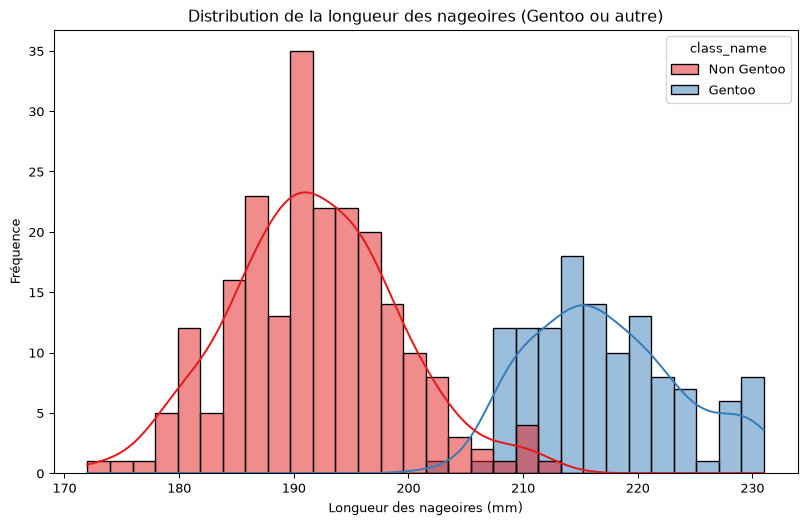

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from palmerpenguins import load_penguins
from sklearn.datasets import load_digits, load_iris
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, label_binarize

# Charger le jeu de données Palmer Penguins
penguin_df = load_penguins()[['flipper_length_mm', 'species']].dropna().copy()

# Créer une étiquette binaire : 1 pour Gentoo, 0 autrement
penguin_df['is_gentoo'] = (penguin_df['species'] == 'Gentoo').astype(int)
penguin_df['class_name'] = np.where(
    penguin_df['is_gentoo'] == 1,
    'Gentoo',
    'Non Gentoo'
)

# Séparer les attributs (X) et les étiquettes (y)
penguin_X = penguin_df[['flipper_length_mm']]
penguin_y = penguin_df['is_gentoo']

# Tracer la distribution de la longueur des nageoires selon l'étiquette binaire
plt.figure(figsize=(10, 6))
sns.histplot(
    data=penguin_df,
    x='flipper_length_mm',
    hue='class_name',
    hue_order=['Non Gentoo', 'Gentoo'],
    kde=True,
    bins=30,
    palette='Set1'
)
plt.title('Distribution de la longueur des nageoires (Gentoo ou autre)')
plt.xlabel('Longueur des nageoires (mm)')
plt.ylabel('Fréquence')
plt.show()

## Régression logistique (logit)

- Malgré son nom, la **régression logistique** est un algorithme de
  **classification**, et non une technique de régression.

- Les **étiquettes** de la régression logistique sont des valeurs
  binaires, notées $y_i \in \{0,1\}$; il s’agit donc d’une **tâche de
  classification binaire**.

- L’objectif principal de la régression logistique est de déterminer la
  **probabilité** qu’une instance $x_i$ appartienne à la **classe
  positive**, c’est-à-dire que $y_i = 1$.

La représentation des classes **négative** et **positive** par les
valeurs 0 et 1 n’est pas arbitraire. Elle est directement liée à notre
objectif : déterminer la **probabilité** qu’une instance $x_i$
appartienne à la classe positive.

Même si cet algorithme peut sembler banal au premier abord, il faut bien
le comprendre : la régression logistique jouera plus tard un rôle
essentiel dans notre étude des réseaux de neurones artificiels.

## Modèle

- **Cas général :** $P(y = k | x, \theta)$, où $k$ est une étiquette de
  classe.
- **Cas binaire :** $y \in \{0,1\}$
  - **Prédire** $P(y = 1 | x, \theta)$

## Visualisation des données

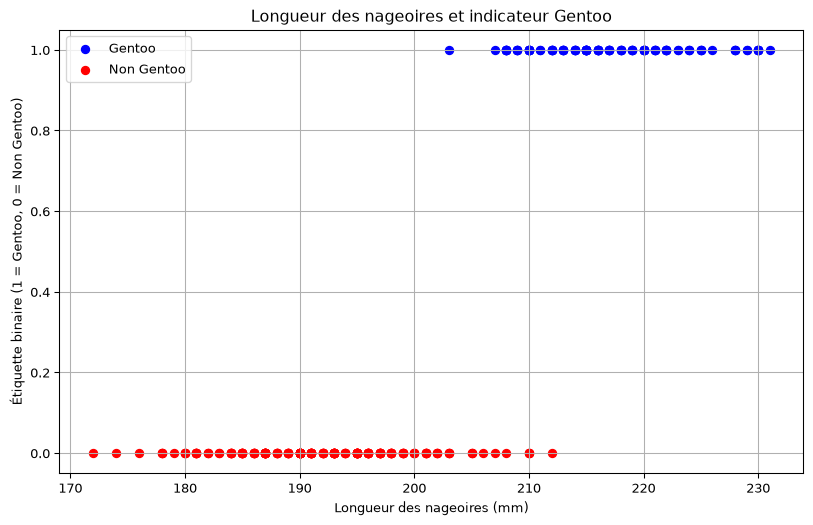

In [3]:
# Nuage de points : longueur des nageoires et étiquette binaire
plt.figure(figsize=(10, 6))

# Tracer les points Gentoo (is_gentoo = 1)
plt.scatter(
    penguin_df.loc[penguin_df['is_gentoo'] == 1, 'flipper_length_mm'],
    penguin_df.loc[penguin_df['is_gentoo'] == 1, 'is_gentoo'],
    color='blue',
    label='Gentoo'
)

# Tracer les points non Gentoo (is_gentoo = 0)
plt.scatter(
    penguin_df.loc[penguin_df['is_gentoo'] == 0, 'flipper_length_mm'],
    penguin_df.loc[penguin_df['is_gentoo'] == 0, 'is_gentoo'],
    color='red',
    label='Non Gentoo'
)

plt.title('Longueur des nageoires et indicateur Gentoo')
plt.xlabel('Longueur des nageoires (mm)')
plt.ylabel('Étiquette binaire (1 = Gentoo, 0 = Non Gentoo)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## Intuition

Ajuster une régression linéaire n’est pas la solution, mais $\ldots$

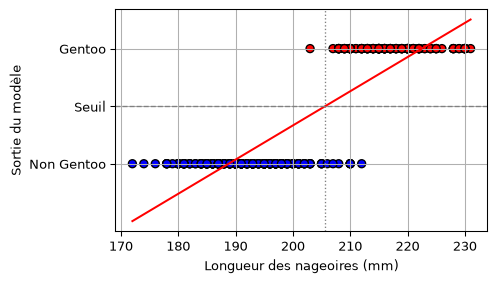

In [4]:
penguin_linear_model = LinearRegression()
penguin_linear_model.fit(penguin_X, penguin_y)

penguin_line_X = pd.DataFrame({
    'flipper_length_mm': np.linspace(
        penguin_X['flipper_length_mm'].min(),
        penguin_X['flipper_length_mm'].max(),
        200
    )
})
penguin_line_y = penguin_linear_model.predict(penguin_line_X)

# Le seuil se trouve là où la droite ajustée atteint 0.5.
linear_boundary_mm = float(
    (0.5 - penguin_linear_model.intercept_) /
    penguin_linear_model.coef_[0]
)

def plot_penguin_linear_fit():
    plt.figure(figsize=(5, 3))
    plt.scatter(
        penguin_X['flipper_length_mm'],
        penguin_y,
        c=penguin_y,
        cmap='bwr',
        edgecolor='k'
    )
    plt.plot(penguin_line_X['flipper_length_mm'], penguin_line_y, 'r-')
    plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    plt.axvline(linear_boundary_mm, color='gray', linestyle=':', linewidth=1)
    plt.xlabel('Longueur des nageoires (mm)')
    plt.ylabel('Sortie du modèle')
    plt.yticks([0, 0.5, 1], ['Non Gentoo', 'Seuil', 'Gentoo'])
    plt.grid(True)
    plt.show()

plot_penguin_linear_fit()

In [5]:
plot_penguin_linear_fit()

## Intuition (suite)

``` python
plot_penguin_linear_fit()
```

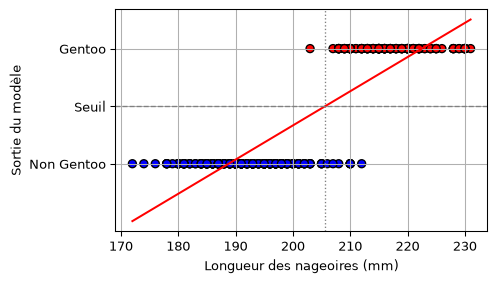

- Une valeur élevée de **`flipper_length_mm`** produit généralement une
  sortie du modèle proche de 1.

- Inversement, une faible valeur de **`flipper_length_mm`** produit
  généralement une sortie proche de 0.

- Les sorties du modèle ne sont toutefois pas limitées à l’intervalle
  \[0, 1\] : elles peuvent être inférieures à 0 ou supérieures à 1.

## Intuition (suite)

``` python
plot_penguin_linear_fit()
```

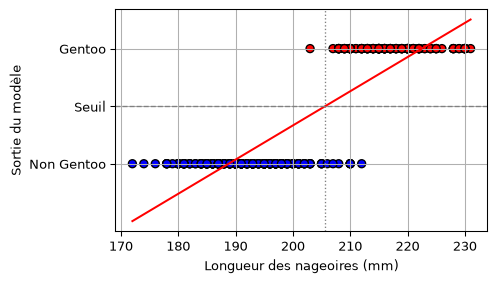

- Avec un **seul attribut**, la frontière de décision est un **point
  précis**.
- Ici, la droite ajustée atteint le seuil de $0.5$ à environ $205.6$ mm.

## Intuition (suite)

``` python
plot_penguin_linear_fit()
```

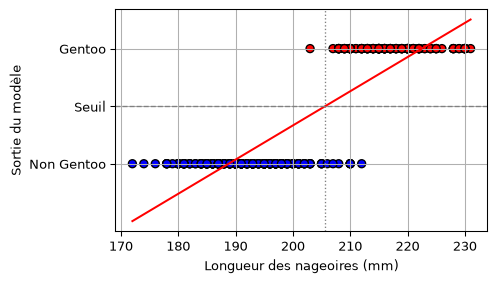

- Lorsque **`flipper_length_mm`** dépasse le seuil, la sortie ajustée se
  rapproche de l’étiquette Gentoo.
- Lorsque **`flipper_length_mm`** descend sous le seuil, la sortie
  ajustée se rapproche de l’étiquette non Gentoo.

## Intuition (suite)

``` python
plot_penguin_linear_fit()
```

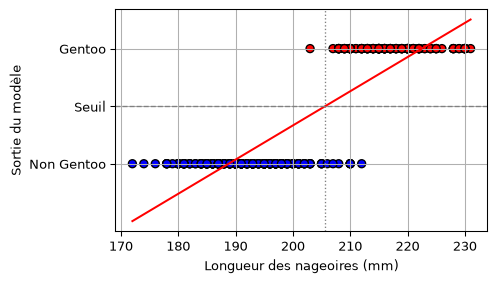

- Près du seuil, la sortie ajustée est proche de $0.5$, mais la
  régression linéaire ne produit toujours pas un modèle probabiliste
  valide.

# Fonction logistique

In [10]:
def sigmoid(t):
    return 1 / (1 + np.exp(-t))

sigmoid_input = np.linspace(-6, 6, 1000)
sigmoid_output = sigmoid(sigmoid_input)

# Ajuster une régression logistique à un attribut afin de distinguer
# son score linéaire de la probabilité obtenue après la sigmoïde.
penguin_logistic_model = LogisticRegression(max_iter=1000)
penguin_logistic_model.fit(penguin_X, penguin_y)

penguin_line_score = penguin_logistic_model.decision_function(penguin_line_X)
logistic_boundary_mm = float(
    -penguin_logistic_model.intercept_[0] /
    penguin_logistic_model.coef_[0, 0]
)

def plot_penguin_logistic_score():
    plt.figure(figsize=(5, 3))
    plt.plot(
        penguin_line_X['flipper_length_mm'],
        penguin_line_score,
        color='blue',
        linewidth=2
    )
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.axvline(logistic_boundary_mm, color='gray', linestyle=':', linewidth=1)
    plt.scatter([logistic_boundary_mm], [0], color='black', zorder=3)
    plt.xlabel('Longueur des nageoires (mm)')
    plt.ylabel(r'Score linéaire $t(x)$')
    plt.grid(True)
    plt.show()

def plot_sigmoid():
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(sigmoid_input, sigmoid_output, color='blue', linewidth=2)
    ax.axvline(x=0, color='black', linewidth=1)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
    ax.scatter([0], [0.5], color='black', zorder=3)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_xlabel('t')
    ax.set_ylabel(r'$\sigma(t)$')
    ax.grid(True)
    plt.show()

plot_sigmoid()

In [11]:
plot_sigmoid()

## Fonction logistique

En mathématiques, la **fonction logistique standard** transforme une
entrée réelle de $\mathbb{R}$ en une valeur dans l’intervalle ouvert
$(0,1)$. Elle est définie ainsi :

$$
  \sigma(t) = \frac{1}{1+e^{-t}}
$$

``` python
plot_sigmoid()
```

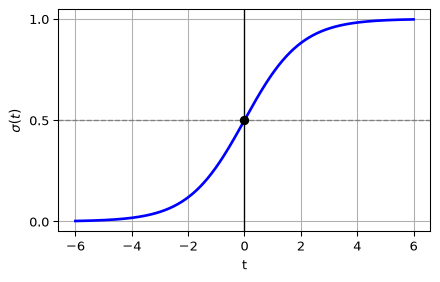

- Lorsque la variable d’entrée $t$ vaut 0, la sortie de la fonction
  logistique vaut 0.5.
  - En effet, $e^{-t} = {e^0} = 1$ et donc
    $\frac{1}{1+e^{-t}} = \frac{1}{1+1}= \frac{1}{2}.$
- Lorsque $t$ augmente, la sortie tend vers 1.
  - Lorsque $t \to \infty$, $e^{-t} \to 0$.
- Inversement, lorsque $t$ devient de plus en plus négatif, la sortie
  tend vers 0.
  - Lorsque $t \to -\infty$, $e^{-t} \to \infty$ (les deux signes
    négatifs s’annulent).
- La fonction logistique standard est aussi communément appelée
  **fonction sigmoïde**.

## Score linéaire et probabilité

``` python
plot_penguin_logistic_score()
```

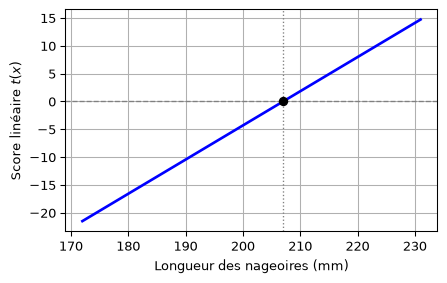

``` python
plot_sigmoid()
```

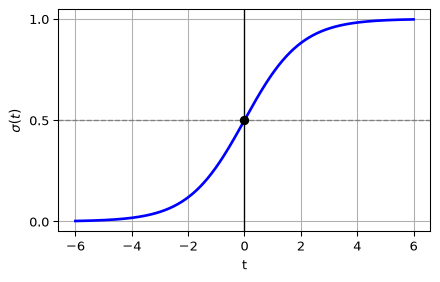

- Le score linéaire ajusté $t(x)=\theta_0+\theta_1x$ est nul à la
  frontière de décision, qui se situe à environ $207$ mm dans cet
  exemple.
- La sigmoïde transforme ce score nul en $P(y=1\mid x)=0.5$. Les scores
  négatifs correspondent à des probabilités inférieures à $0.5$, et les
  scores positifs à des probabilités supérieures à $0.5$.

## Fonction logistique

Une courbe en S, comme la fonction logistique standard (ou
**sigmoïde**), est appelée **fonction d’écrasement**, car elle
transforme un vaste domaine d’entrée en un intervalle de sortie
restreint.

$$
  \sigma(t) = \frac{1}{1+e^{-t}}
$$

``` python
plot_sigmoid()
```

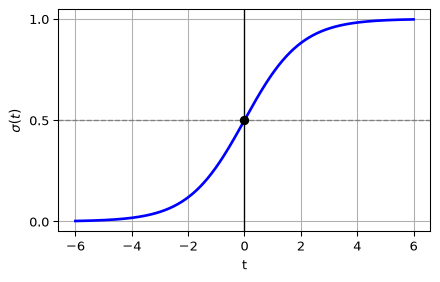

## Régression logistique (logit)

- À l’instar de la **régression linéaire**, la **régression logistique**
  calcule une somme pondérée des attributs d’entrée : $$
  \theta_0 + \theta_1 x_i^{(1)} + \theta_2 x_i^{(2)} + \ldots + \theta_D x_i^{(D)}
  $$

- Toutefois, la fonction sigmoïde limite la sortie à l’intervalle
  $(0,1)$ : $$
  \sigma(\theta_0 + \theta_1 x_i^{(1)} + \theta_2 x_i^{(2)} + \ldots + \theta_D x_i^{(D)})
  $$

## Notation

- Équation de la **régression logistique** : $$
  \sigma(\theta_0 + \theta_1 x_i^{(1)} + \theta_2 x_i^{(2)} + \ldots + \theta_D x_i^{(D)})
  $$

- Multiplier $\theta_0$ (ordonnée à l’origine ou biais) **par 1** : $$
  \sigma(\theta_0 \times 1 + \theta_1 x_i^{(1)} + \theta_2 x_i^{(2)} + \ldots + \theta_D x_i^{(D)})
  $$

- Multiplier $\theta_0$ par $x_i^{(0)} = 1$ : $$
  \sigma(\theta_0 x_i^{(0)} + \theta_1 x_i^{(1)} + \theta_2 x_i^{(2)} + \ldots + \theta_D x_i^{(D)})
  $$

## Régression logistique

Sous sa forme vectorisée, le modèle de **régression logistique** est
défini ainsi :

$$
  h_\theta(x_i) = \sigma(\theta^\top x_i) = \frac{1}{1+e^{-\theta^\top x_i}}
  $$

Un attribut supplémentaire, $x_i^{(0)} = 1$, a été ajouté à $x_i$, et
$\theta_0$ est l’ordonnée à l’origine, ou biais.

In [16]:
penguin_features = ['bill_depth_mm', 'body_mass_g']
penguin_two_feature_df = load_penguins()[penguin_features + ['species']].dropna().copy()
penguin_two_feature_df['is_gentoo'] = (
    penguin_two_feature_df['species'] == 'Gentoo'
).astype(int)

penguin_two_X = penguin_two_feature_df[penguin_features].to_numpy()
penguin_two_y = penguin_two_feature_df['is_gentoo'].to_numpy()

penguin_two_X_train, penguin_two_X_test, penguin_two_y_train, penguin_two_y_test = train_test_split(
    penguin_two_X,
    penguin_two_y,
    test_size=0.2,
    random_state=42,
    stratify=penguin_two_y
)

penguin_two_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)
penguin_two_model.fit(penguin_two_X_train, penguin_two_y_train)

def plot_penguin_decision_boundary(X_values, y_values, fitted_model):
    bill_depth = np.linspace(X_values[:, 0].min() - 1, X_values[:, 0].max() + 1, 200)
    body_mass = np.linspace(X_values[:, 1].min() - 200, X_values[:, 1].max() + 200, 200)
    depth_grid, mass_grid = np.meshgrid(bill_depth, body_mass)
    grid = np.column_stack([depth_grid.ravel(), mass_grid.ravel()])
    predicted_class = fitted_model.predict(grid).reshape(depth_grid.shape)

    plt.figure(figsize=(9, 4))
    plt.contourf(depth_grid, mass_grid, predicted_class, alpha=0.3, cmap='RdYlBu')
    plt.scatter(
        X_values[y_values == 1, 0],
        X_values[y_values == 1, 1],
        color='orange',
        edgecolors='k',
        label='Gentoo'
    )
    plt.scatter(
        X_values[y_values == 0, 0],
        X_values[y_values == 0, 1],
        color='blue',
        edgecolors='k',
        label='Non Gentoo'
    )
    plt.xlabel('Profondeur du bec (mm)')
    plt.ylabel('Masse corporelle (g)')
    plt.title('Régions de décision de la régression logistique')
    plt.legend()
    plt.show()

plot_penguin_decision_boundary(
    penguin_two_X_train,
    penguin_two_y_train,
    penguin_two_model
)

In [17]:
plot_penguin_decision_boundary(
    penguin_two_X_train,
    penguin_two_y_train,
    penguin_two_model
)

## Régression logistique (deux attributs)

``` python
plot_penguin_decision_boundary(
    penguin_two_X_train,
    penguin_two_y_train,
    penguin_two_model
)
```

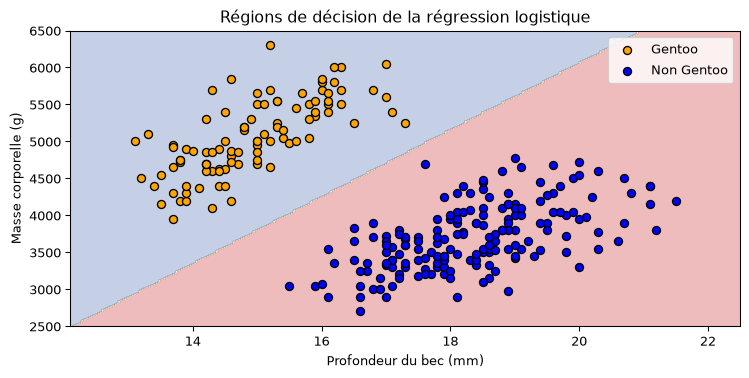

$$
  h_\theta(x_i) = \sigma(\theta^\top x_i)
$$

- Le signe de $\theta^\top x_i$ détermine de quel côté de la frontière
  de décision se trouve l’exemple.
- Plus le score devient positif ou négatif, plus la probabilité du
  modèle s’éloigne de $0.5$.
- Sur la frontière de décision, $\theta^\top x_i=0$ et le modèle
  attribue une probabilité de $0.5$ à chaque classe.

## Régression logistique

- Sous sa forme vectorisée, le modèle de **régression logistique** est
  défini ainsi :

  $$
  h_\theta(x_i) = \sigma(\theta^\top x_i) = \frac{1}{1+e^{-\theta^\top x_i}}
  $$

- Les **prédictions** sont obtenues comme suit :

  - $\hat{y}_i = 0$ si $h_\theta(x_i) < 0.5$, ce qui équivaut à
    $\theta^\top x_i < 0$
  - $\hat{y}_i = 1$ si $h_\theta(x_i) \geq 0.5$, ce qui équivaut à
    $\theta^\top x_i \geq 0$

. . .

- Les paramètres $\theta$ sont appris en minimisant une fonction de
  perte. Le prochain cours dérive cette fonction et applique la descente
  de gradient.

------------------------------------------------------------------------

<https://youtu.be/yIYKR4sgzI8>

**Attribution :** [StatQuest: Logistic
Regression](https://youtu.be/yIYKR4sgzI8), par Josh Starmer.

StatQuest décompose les méthodes complexes de statistique et
d’apprentissage automatique en petits éléments faciles à comprendre. La
chaîne ne simplifie pas le contenu à outrance; elle développe plutôt
progressivement la compréhension. C’est souvent un bon point de départ
pour acquérir l’intuition nécessaire aux concepts statistiques et à
l’apprentissage automatique.

# Exemple des chiffres

## 1989 Yann LeCun

<https://www.youtube.com/watch?v=H0oEr40YhrQ>

## Reconnaissance de chiffres manuscrits

### Objectif :

- Développer un **modèle de régression logistique** pour la
  **reconnaissance de chiffres manuscrits**.

- Visualiser les **informations** et les **motifs** appris par le
  modèle.

Nous utilisons le [jeu de données UCI ML sur les chiffres
manuscrits](https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits).

## Jeu de données UCI ML sur les chiffres manuscrits

Charger le jeu de données

In [19]:
digits = load_digits()

Quel est le type de `digits.data`?

In [20]:
type(digits.data)

numpy.ndarray

Développer un **modèle de régression logistique** pour la
**reconnaissance de chiffres manuscrits**.

## Jeu de données UCI ML sur les chiffres manuscrits

Combien y a-t-il d’exemples (`N`) et d’attributs (`D`)?

In [21]:
digits.data.shape

(1797, 64)

Attribuer des valeurs à `N` et `D`

In [22]:
digit_count, digit_feature_count = digits.data.shape

`target` contient-il le même nombre d’entrées (exemples) que `data`?

In [23]:
digits.target.shape

(1797,)

## Jeu de données UCI ML sur les chiffres manuscrits

Quelles sont la largeur et la hauteur de ces images?

In [24]:
digits.images.shape

(1797, 8, 8)

Attribuer des valeurs à `height` et `width`

In [25]:
_, digit_height, digit_width = digits.images.shape

## Jeu de données UCI ML sur les chiffres manuscrits

Attribuer des valeurs à `digits_X` et `digits_y`

In [26]:
digits_X = digits.data
digits_y = digits.target

## Jeu de données UCI ML sur les chiffres manuscrits

`digits_X[0]` est un vecteur de taille `digit_height * digit_width = D`
($8 \times 8 = 64$).

In [27]:
digits_X[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

. . .

Il correspond à une image de $8 \times 8 = 64$ pixels.

In [28]:
digits_X[0].reshape(digit_height, digit_width)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

## Jeu de données UCI ML sur les chiffres manuscrits

Tracer les `n=5` premiers exemples

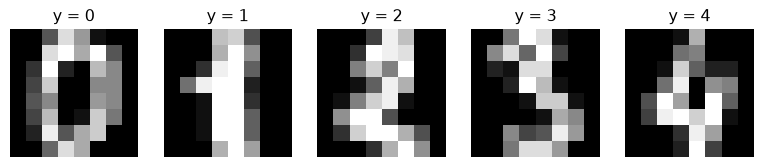

In [29]:
def plot_digit_examples(X_values, y_values, count=5):
    plt.figure(figsize=(10, 2))
    for index, (image, label) in enumerate(zip(X_values[:count], y_values[:count])):
        plt.subplot(1, count, index + 1)
        plt.imshow(image.reshape(digit_height, digit_width), cmap=plt.cm.gray)
        plt.title(f'y = {label}')
        plt.axis('off')
    plt.show()

plot_digit_examples(digits_X, digits_y)

Les intensités proches de 0 sont représentées en noir, tandis que les
valeurs élevées sont représentées en blanc.

Utilisez `cmap=plt.cm.binary` pour inverser les images (valeurs proches
de 0 en blanc et valeurs élevées en noir).

## Jeu de données UCI ML sur les chiffres manuscrits

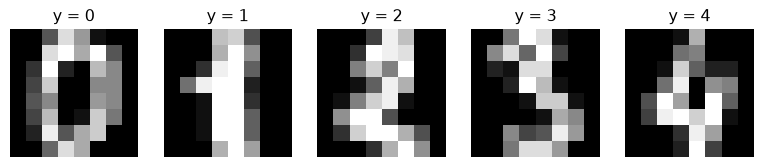

In [30]:
plot_digit_examples(digits_X, digits_y)

- Dans notre jeu de données, chaque $x_i$ est un **vecteur d’attributs**
  de taille $D = 64$.

- Ce vecteur est formé en concaténant les lignes d’une image de
  $8 \times 8$ pixels.

- La fonction `reshape` reconvertit ce vecteur à 64 dimensions dans son
  format d’image original de $8 \times 8$.

## Jeu de données UCI ML sur les chiffres manuscrits

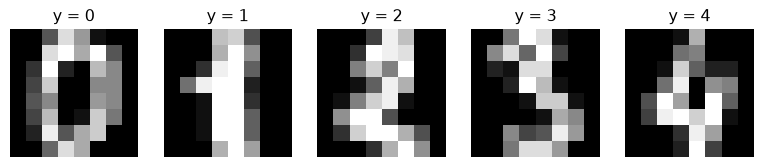

In [31]:
plot_digit_examples(digits_X, digits_y)

- Nous entraînerons **10 classificateurs**, chacun correspondant à un
  chiffre précis dans une approche **un contre tous (OvR)**.

- Chaque classificateur déterminera les valeurs optimales des $\theta_j$
  associés aux pixels, afin de distinguer un chiffre de tous les autres.

## Jeu de données UCI ML sur les chiffres manuscrits

Préparer l’expérience d’apprentissage automatique

In [32]:
digits_X_train, digits_X_test, digits_y_train, digits_y_test = train_test_split(
    digits_X,
    digits_y,
    test_size=0.1,
    random_state=42,
    stratify=digits_y
)

## Jeu de données UCI ML sur les chiffres manuscrits

Les algorithmes d’optimisation fonctionnent généralement mieux lorsque
les attributs ont des échelles comparables.

In [33]:
digit_scaler = StandardScaler()
digits_X_train_scaled = digit_scaler.fit_transform(digits_X_train)
digits_X_test_scaled = digit_scaler.transform(digits_X_test)

**Discussion :** pourquoi faut-il appliquer `fit_transform` uniquement à
`digits_X_train`?

L’optimisation se comporte généralement mieux lorsque les attributs ont
des échelles comparables.

[StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
est une méthode courante. Pour un attribut donné, les valeurs sont
transformées ainsi :

$$
z = (x - \mu) / \sigma
$$

où $\mu$ est la moyenne de cet attribut dans les données d’entraînement,
et $\sigma$ son écart-type.

L’appel à `fit` apprend la moyenne et l’écart-type de chaque attribut.
L’appel à `transform` applique la transformation apprise.
`fit_transform` combine ces deux opérations.

Ajuster le normalisateur sur l’ensemble complet provoquerait une **fuite
de données**, car l’information de l’ensemble de test influencerait la
transformation utilisée pendant l’entraînement.

Les données de test doivent tout de même être transformées, mais avec la
moyenne et l’écart-type appris sur les données d’entraînement. Le
normalisateur ajusté fait donc partie du système entraîné.

## Jeu de données UCI ML sur les chiffres manuscrits

In [34]:
digit_classifier = OneVsRestClassifier(LogisticRegression(max_iter=1000))
digit_classifier.fit(digits_X_train_scaled, digits_y_train)

Le classificateur résout la tâche multiclasse au moyen de la stratégie
**un contre tous (OvR)**. Les classificateurs de scikit-learn offrent
une [prise en charge
multiclasse](https://scikit-learn.org/stable/modules/multiclass.html).

Chaque régression logistique trouve un **hyperplan** dans un **espace à
64 dimensions** qui sépare les données en deux classes.

## Jeu de données UCI ML sur les chiffres manuscrits

Appliquer le classificateur à l’ensemble de test

In [35]:
digits_y_pred = digit_classifier.predict(digits_X_test_scaled)
digit_test_accuracy = accuracy_score(digits_y_test, digits_y_pred)
print(f'Exactitude sur le test : {digit_test_accuracy:.3f}')

Exactitude sur le test : 0.967

Le cours 7 présente en détail les mesures de performance.

## Visualisation

Combien y a-t-il de classes?

In [36]:
digit_classifier.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

. . .

Les coefficients et les ordonnées à l’origine se trouvent dans des
tableaux distincts.

In [37]:
(digit_classifier.estimators_[0].coef_.shape,
 digit_classifier.estimators_[0].intercept_.shape)

((1, 64), (1,))

. . .

L’ordonnée à l’origine est $\theta_0$. Les 64 coefficients des attributs
sont les $\theta_j$, pour $j \in \{1,\ldots,64\}$.

Adapté de [MNIST digits classification using Logistic regression in
Scikit-Learn](https://atmamani.github.io/projects/ml/mnist-digits-classification-using-logistic-regression-scikit-learn/),
consulté le 23 septembre 2024.

## Visualisation

In [38]:
digit_classifier.estimators_[0].coef_[0].round(2).reshape(
    digit_height,
    digit_width
)

array([[ 0.  , -0.14, -0.  ,  0.21, -0.01, -0.66, -0.46, -0.05],
       [ 0.  , -0.22, -0.05,  0.43,  0.57,  0.9 ,  0.02, -0.19],
       [-0.03,  0.28,  0.43, -0.18, -0.94,  0.82,  0.04, -0.13],
       [-0.04,  0.21,  0.11, -0.63, -1.78,  0.09,  0.23, -0.04],
       [ 0.  ,  0.35,  0.5 , -0.6 , -1.73, -0.02,  0.03,  0.  ],
       [-0.15, -0.13,  0.86, -0.97, -0.73,  0.1 ,  0.26,  0.02],
       [-0.07, -0.3 ,  0.44,  0.09,  0.25,  0.05, -0.4 , -0.47],
       [ 0.02, -0.26, -0.43,  0.43, -0.59, -0.08, -0.28, -0.28]])

## Visualisation

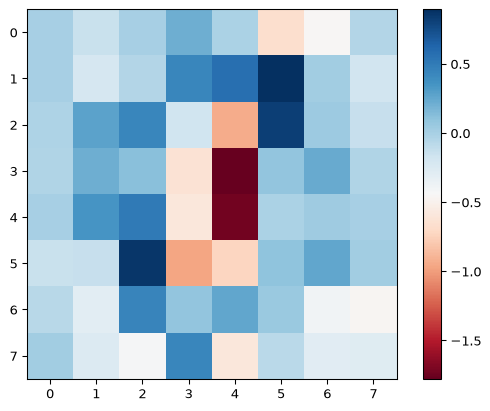

In [39]:
digit_zero_coefficients = digit_classifier.estimators_[0].coef_[0]
plt.imshow(
    digit_zero_coefficients.reshape(digit_height, digit_width),
    cmap=plt.cm.RdBu
)
plt.colorbar()
plt.show()

## Visualisation

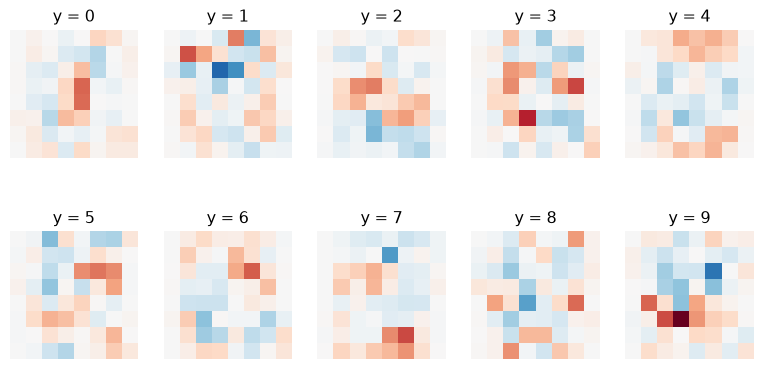

In [40]:
plt.figure(figsize=(10,5))
max_abs_coefficient = max(
    np.abs(estimator.coef_).max()
    for estimator in digit_classifier.estimators_
)

for index, class_label in enumerate(digit_classifier.classes_):
    plt.subplot(2, 5, index + 1)
    plt.title(f'y = {class_label}')
    plt.imshow(
        digit_classifier.estimators_[index].coef_.reshape(
            digit_height,
            digit_width
        ),
        cmap=plt.cm.RdBu,
        vmin=-max_abs_coefficient,
        vmax=max_abs_coefficient
    )
    plt.axis('off')
plt.show()

Chaque modèle binaire `LogisticRegression` apprend 64 coefficients
d’attributs et une ordonnée à l’origine, soit 65 paramètres.

Ces coefficients s’appliquent aux intensités de pixels standardisées
utilisées pendant l’entraînement.

Les pixels rouges correspondent aux coefficients négatifs, et les pixels
bleus aux coefficients positifs. Les dix cartes utilisent la même
échelle de couleurs.

Pour le classificateur qui reconnaît le zéro, les pixels de forte
intensité au centre réduisent le score de la classe, tandis que les
pixels disposés sur l’ovale qui les entoure l’augmentent.

------------------------------------------------------------------------

<https://youtu.be/AX-ZEC-71DI>

**Attribution :** [Machine Learning and Logistic
Regression](https://youtu.be/AX-ZEC-71DI), IBM Technology, 19 juillet
2024.

# Épilogue

## Sommaire

- La régression logistique transforme le score linéaire
  $\theta^\top x_i$ en probabilité $P(y_i=1\mid x_i,\theta)$ à l’aide de
  la fonction sigmoïde.
- Le seuil $h_\theta(x_i)=0.5$ correspond à la frontière de décision
  linéaire $\theta^\top x_i=0$.
- Une probabilité produite par le modèle estime l’appartenance à une
  classe; ce n’est pas la probabilité que l’étiquette prédite soit
  correcte.
- La stratégie **un contre tous** entraîne un classificateur binaire
  pour chaque classe et sélectionne celle dont le score est le plus
  élevé.
- Le prétraitement doit être ajusté sur l’ensemble d’entraînement, puis
  appliqué sans changement à l’ensemble de test.
- Les coefficients appris indiquent comment chaque attribut modifie le
  score linéaire d’un classificateur.

## Références

Alharbi, Fadi, et Aleksandar Vakanski. 2023. « Machine Learning Methods
for Cancer Classification Using Gene Expression Data: A Review ».
*Bioengineering* 10 (2): 173.
<https://doi.org/10.3390/bioengineering10020173>.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

Wu, Qianfan, Adel Boueiz, Alican Bozkurt, et al. 2018. « [Deep Learning
Methods for Predicting Disease Status Using Genomic
Data](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6530791) ». *Journal
of biometrics & biostatistics* 9 (5).

Zhao, Celina. 2026. « OpenAI breakthrough triggers “existential crisis”
in math ». *Science*, publication en ligne anticipée, septembre.
<https://doi.org/10.1126/science.zbgmw3q>.

## Ressources

- [Logistic Regression 3-class
  Classifier](https://scikit-learn.org/stable/auto_examples/linear_model/plot_iris_logistic.html),
  dans `sklearn`

## Prochain cours

- Log-vraisemblance négative, interprétation géométrique et mise en
  œuvre

# Annexe

## Classificateur un contre tous

In [41]:
# Charger le jeu de données Iris
iris = load_iris()
iris_X, iris_y = iris.data, iris.target

# Binariser la sortie
iris_y_binarized = label_binarize(iris_y, classes=[0, 1, 2])

# Diviser les données en ensembles d'entraînement et de test
iris_X_train, iris_X_test, iris_y_train, iris_y_test = train_test_split(
    iris_X,
    iris_y_binarized,
    test_size=0.2,
    random_state=42,
    stratify=iris_y
)

## Classificateur un contre tous

In [42]:
# Entraîner un classificateur binaire pour chaque classe

iris_classifiers = []
for class_index in range(len(iris.target_names)):
    iris_classifier = LogisticRegression(max_iter=1000)
    iris_classifier.fit(iris_X_train, iris_y_train[:, class_index])
    iris_classifiers.append(iris_classifier)

Chaque régression logistique trouve un **hyperplan** dans un **espace à
4 dimensions** qui sépare les données en deux classes.

## Classificateur un contre tous

In [43]:
# Prédire la classe d'un nouvel exemple
new_sample = iris_X_test[0].reshape(1, -1)
confidence_scores = np.array([
    classifier.decision_function(new_sample).item()
    for classifier in iris_classifiers
])

# Attribution finale
final_class = np.argmax(confidence_scores)

# Afficher le résultat
print(f"Classe attribuée : {iris.target_names[final_class]}")
print(f"Classe réelle : {iris.target_names[np.argmax(iris_y_test[0])]}")

Classe attribuée : setosa
Classe réelle : setosa

## `label_binarize`

In [44]:
# Étiquettes de classe originales
example_labels = np.array([0, 1, 2, 0, 1, 2, 1, 0])

# Binariser les étiquettes
example_labels_binarized = label_binarize(example_labels, classes=[0, 1, 2])

print("Étiquettes binarisées :\n", example_labels_binarized)

# Reconvertir les étiquettes binarisées en valeurs numériques originales
original_labels = [np.argmax(label_vector) for label_vector in example_labels_binarized]
print("Étiquettes originales :\n", original_labels)

Étiquettes binarisées :
 [[1 0 0]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]]
Étiquettes originales :
 [np.int64(0), np.int64(1), np.int64(2), np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(0)]

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de génie électrique et d’**informatique** (**ÉÉ**CS)

Université d’Ottawa

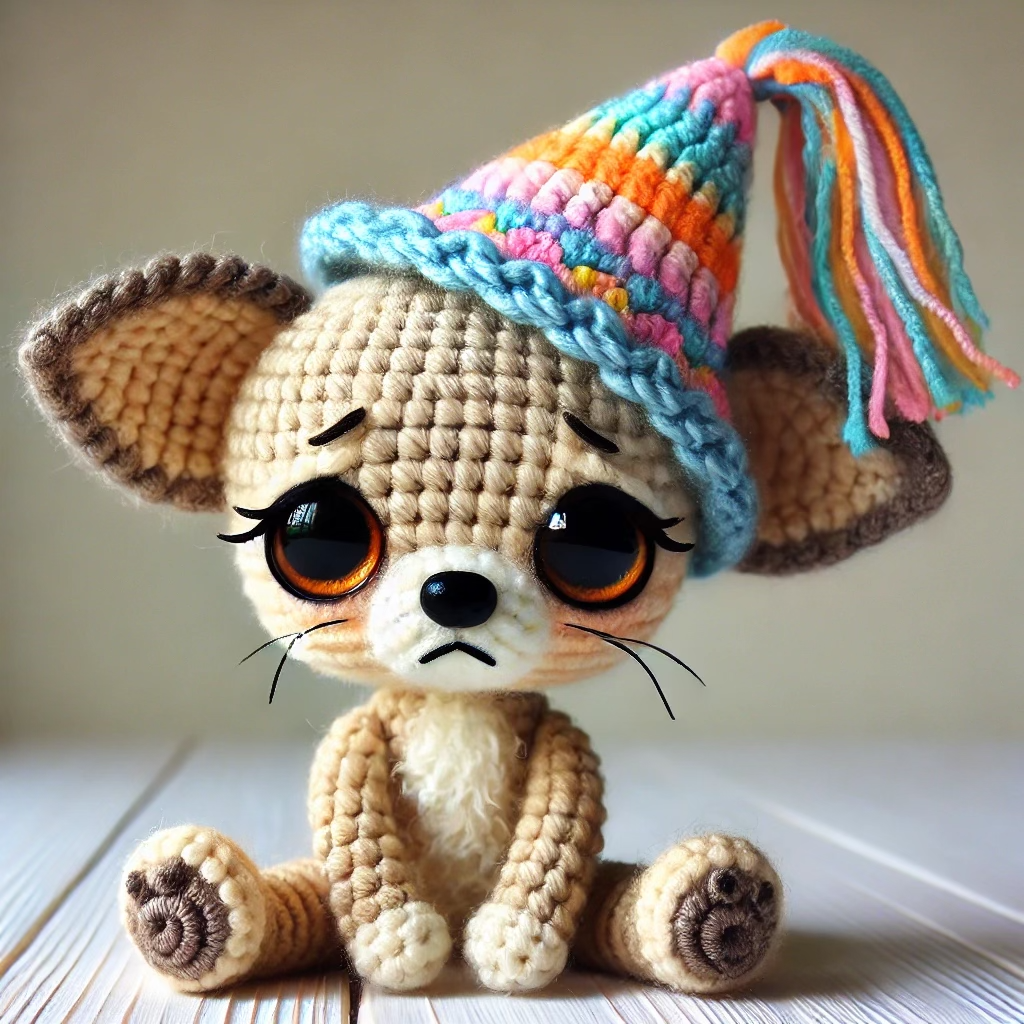

**Attribution :** « Une image d’un amigurumi de chihuahua triste coiffé
d’un chapeau d’anniversaire. » Générée par DALL-E, par l’entremise de
ChatGPT (GPT-4), OpenAI, le 16 septembre 2024.